In [1]:
import numpy as np
import sys
import os
import VBMicrolensing
import emcee
import h5py
import math
import matplotlib.pyplot as plt
import concurrent.futures
import corner
from tqdm import tqdm
VBM = VBMicrolensing.VBMicrolensing()
JD0 = 2450000
from matplotlib.lines import Line2D
sys.path.append("/moao38_7/nunota/genulens/genprior/gentool/")
from gapmoe import gapmoe

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap

In [2]:
import matplotlib as mpl
mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [3]:
labels_phys_muEN = [
    r"$\log_{10}(M_{\rm L}/M_\odot)$",
    r"$\log_{10}(D_{\rm L}/{\rm kpc})$",
    r"$\log_{10}(D_{\rm S}/{\rm kpc})$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$"
]

In [4]:
column_names = " wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L iS iL fREM".strip().split()

path_prior = "../test_gal_result/genout_prior.dat"
data_gal_prior = np.genfromtxt(path_prior, names=column_names)

data_gal_muN = data_gal_prior["mu_rel"] * np.cos(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
data_gal_muE = data_gal_prior["mu_rel"] * np.sin(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
mu_tot_flat = np.sqrt(data_gal_muN**2 + data_gal_muE**2)
mask_flat = mu_tot_flat < 20

flat_prior_log_data = np.vstack([
    np.log10(data_gal_prior["M_L"][mask_flat]),
    np.log10(data_gal_prior["D_L"][mask_flat] * 1e-3),
    np.log10(data_gal_prior["D_S"][mask_flat] * 1e-3),
    data_gal_muN[mask_flat],
    data_gal_muE[mask_flat]
]).T

In [5]:
kappa = 8.144; #mas /MO
G = 2.959122082855911e-4 
thS=0.01

@jit
def calc_physical_params_jax(x):

    tE, rho, s, piEN, piEE, gamma1, gamma2, gamma3 = x
    piE = jnp.sqrt(piEE**2 + piEN**2)
    
    thE = thS / rho
    ML = thE / kappa / piE
    murel = thE / tE * 365.25
    murel_E = murel * piEE / piE
    murel_N = murel * piEN / piE

    gamma_sq = gamma1**2 + gamma2**2 + gamma3**2
    gamma_parallel = jnp.sqrt(gamma1**2 + gamma3**2)
    gamma_ratio = gamma_parallel / gamma3
    orbital_scale = jnp.cbrt((s**3) * gamma_sq * gamma_ratio / (ML * G))
    gamma_abs = jnp.sqrt(gamma_sq)
    Ds = 1 / ((orbital_scale - piE) * thE)

    pi_rel = thE * piE
    pi_S = 1 / Ds
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L

    RE = DL * thE
    orbital_radi = RE * s * gamma_parallel / gamma3

    cosi = gamma3 * gamma2 / (gamma_parallel * gamma_abs)
    tanphi = - gamma1 * gamma_abs / (gamma3 * gamma_parallel)

    return jnp.array([murel_E, murel_N, ML, DL, Ds, orbital_radi, cosi, tanphi])

In [6]:
prior_variants = [
    {  # Variant 1 (Default)
        "name": "Prior A",
        "color": "C1",
        "bounds": {
            "tE":    (0, 1000),
            "rho":   (0, 1),
            "s":     (0, 10),
            "piEN":  (-3, 3),
            "piEE":  (-3, 3),
            "gamma1": (-1, 1),
            "gamma2": (-1, 1),
            "gamma3": (-1, 1),
        }
    },
    {  # Variant 2 (Tighter)
        "name": "Prior B",
        "color": "C2",
        "bounds": {
            "tE":    (0, 1000),
            "rho":   (0, 1),
            "s":     (0, 10),
            "piEN":  (-3, 3),
            "piEE":  (-3, 3),
            "gamma1": (-0.05, 0.05),
            "gamma2": (-0.05, 0.05),
            "gamma3": (-0.05, 0.05),
        }
    },
    {  # Variant 3 (Wide)
        "name": "Prior C",
        "color": "C3",
        "bounds": {
            "tE":    (0, 1000),
            "rho":   (0, 1),
            "s":     (0, 10),
            "piEN":  (-3, 3),
            "piEE":  (-3, 3),
            "gamma1": (-0.01, 0.01),
            "gamma2": (-0.01, 0.01),
            "gamma3": (-0.01, 0.01),
        }
    }
]


In [7]:
def generate_nonuni_log_data(bounds_dict, N=100000):
    rng = np.random.default_rng(seed=42)
    samples = np.stack([
        rng.uniform(low, high, N)
        for (low, high) in bounds_dict.values()
    ], axis=-1)
    
    physical_params = vmap(calc_physical_params_jax)(jnp.array(samples))
    
    ML = np.array(physical_params[:, 2])
    DL = np.array(physical_params[:, 3])
    DS = np.array(physical_params[:, 4])
    muN = np.array(physical_params[:, 0])
    muE = np.array(physical_params[:, 1])

    valid_mask = (DL > 0) & (DS > 0)
    ML = ML[valid_mask]
    DL = DL[valid_mask]
    DS = DS[valid_mask]
    muN = muN[valid_mask]
    muE = muE[valid_mask]

    mu_tot = np.sqrt(muN**2 + muE**2)
    mask = mu_tot < 20

    log_data = np.vstack([
        np.log10(ML[mask]),
        np.log10(DL[mask]),
        np.log10(DS[mask]),
        muN[mask],
        muE[mask]
    ]).T

    return log_data

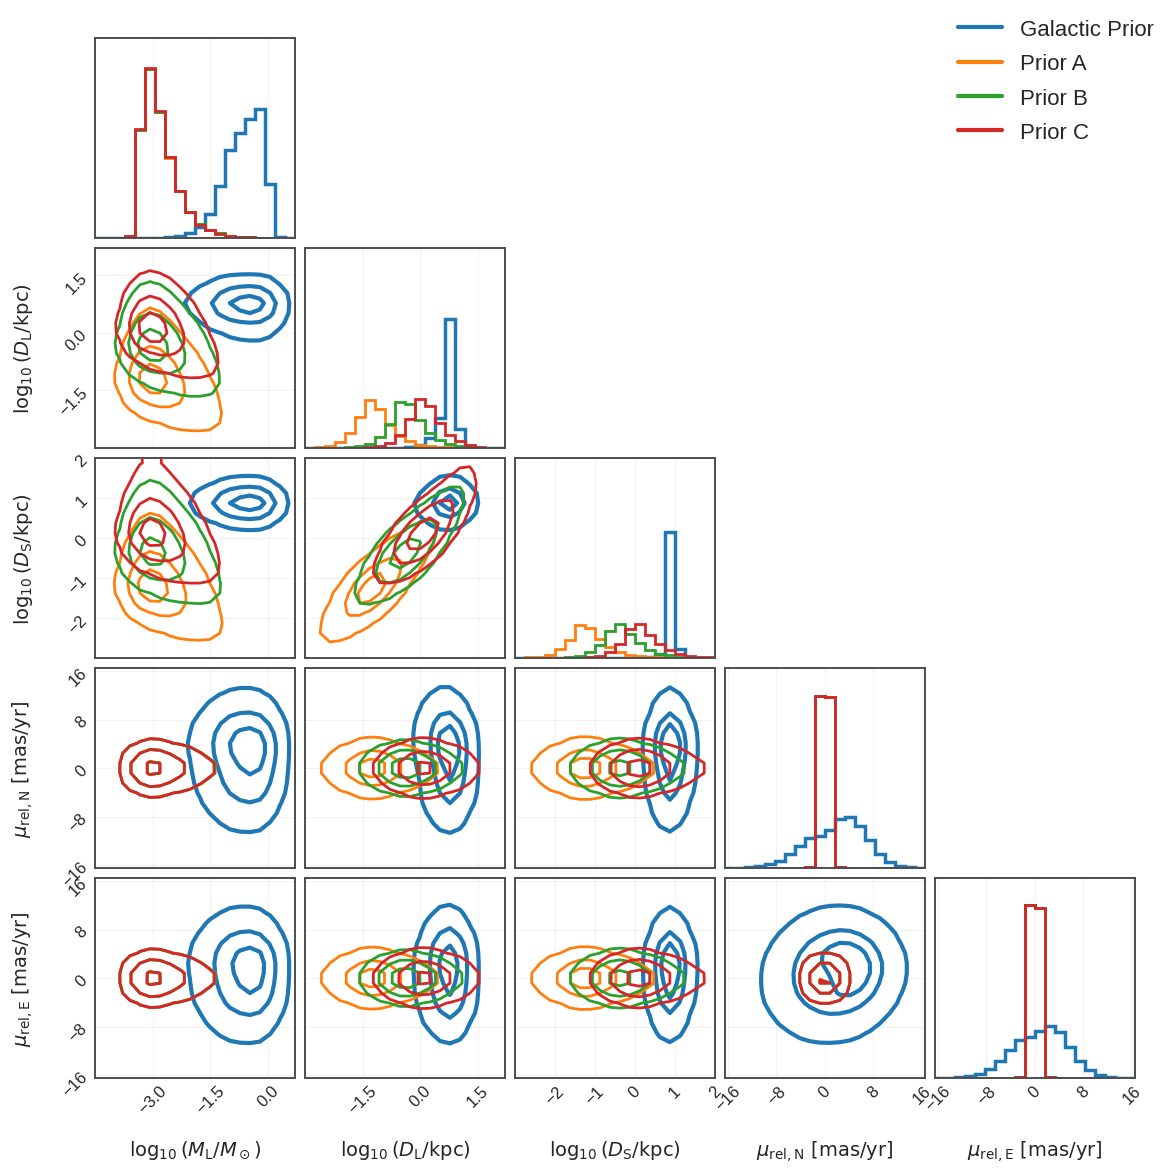

In [8]:
ranges = [
    (-4.5, 0.7),       # logML
    (-3, 2.2),     # logDL
    (-3, 2),    # logDS
    (-16.5, 16.5),         # mu_rel_N
    (-16.5, 16.5)        # mu_rel_E
]

fig = corner.corner(
    flat_prior_log_data,
    labels=labels_phys_muEN,
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    levels=(0.30, 0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=ranges
)

legend_handles = [
    Line2D([0], [0], color="C0", lw=3, label="Galactic Prior")
]

for variant in prior_variants:
    log_data = generate_nonuni_log_data(variant["bounds"])
    corner.corner(
        log_data,
        fig=fig,
        color=variant["color"],
        hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
        contour_kwargs={"zorder": 6, "linewidths": 2, "alpha": 1},
        levels=(0.30, 0.68, 0.95),
        fill_contours=False,
        show_titles=False,
        plot_density=False,
        plot_datapoints=False,
        smooth=1.0,
        range=ranges
    )
    legend_handles.append(
        Line2D([0], [0], color=variant["color"], lw=3, label=variant["name"])
    )

ndim = 5
axes = np.array(fig.axes).reshape((ndim, ndim))
diag_ylims = [1.3, 4, 5.7, 0.35, 0.35]
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)
    axes[i, i].set_ylim(0, diag_ylims[i])

fig.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=16,
    frameon=False,
    labelspacing=0.6,
)

plt.show()

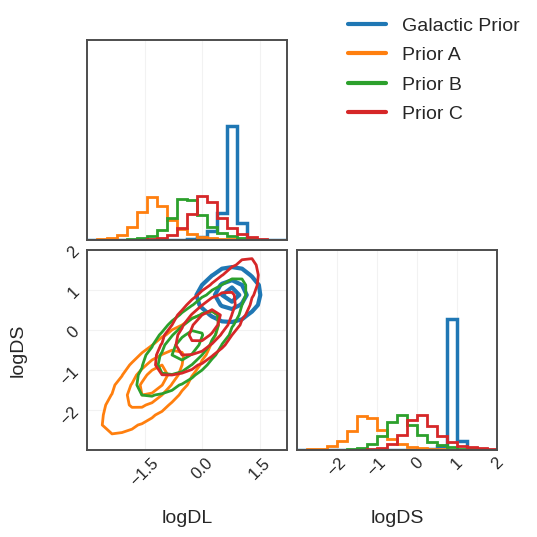

In [9]:
# --- 設定 ---
ranges_2d = [
    (-3, 2.2),     # logDL
    (-3, 2)    # logDS
]
labels_2d = ["logDL", "logDS"]

# --- ベース（Galactic Prior） ---
fig = corner.corner(
    flat_prior_log_data[:, [1, 2]],
    labels=labels_2d,
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    levels=(0.30, 0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=ranges_2d
)

legend_handles = [
    Line2D([0], [0], color="C0", lw=3, label="Galactic Prior")
]

# --- 各一様プライアとの比較 ---
for variant in prior_variants:
    log_data = generate_nonuni_log_data(variant["bounds"])
    corner.corner(
        log_data[:, [1, 2]],  # logDL, logDS
        fig=fig,
        color=variant["color"],
        hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
        contour_kwargs={"zorder": 6, "linewidths": 2, "alpha": 1},
        levels=(0.30, 0.68, 0.95),
        fill_contours=False,
        show_titles=False,
        plot_density=False,
        plot_datapoints=False,
        smooth=1.0,
        range=ranges_2d
    )
    legend_handles.append(
        Line2D([0], [0], color=variant["color"], lw=3, label=variant["name"])
    )

# 軸の微調整
axes = np.array(fig.axes).reshape((2, 2))
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)
axes[0, 0].set_ylim(0, 4.5)
axes[1, 1].set_ylim(0, 5.5)

# 凡例
fig.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=14,
    frameon=False,
    labelspacing=0.6,
)

plt.show()
